In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/csv files/survey lung cancer.csv")
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
df.shape

(309, 16)

In [ ]:
df.isnull().sum()

,0
GENDER,0
AGE,0
SMOKING,0
YELLOW_FINGERS,0
ANXIETY,0
PEER_PRESSURE,0
CHRONIC DISEASE,0
FATIGUE,0
ALLERGY,0
WHEEZING,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['GENDER']=le.fit_transform(df['GENDER'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    int64 
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

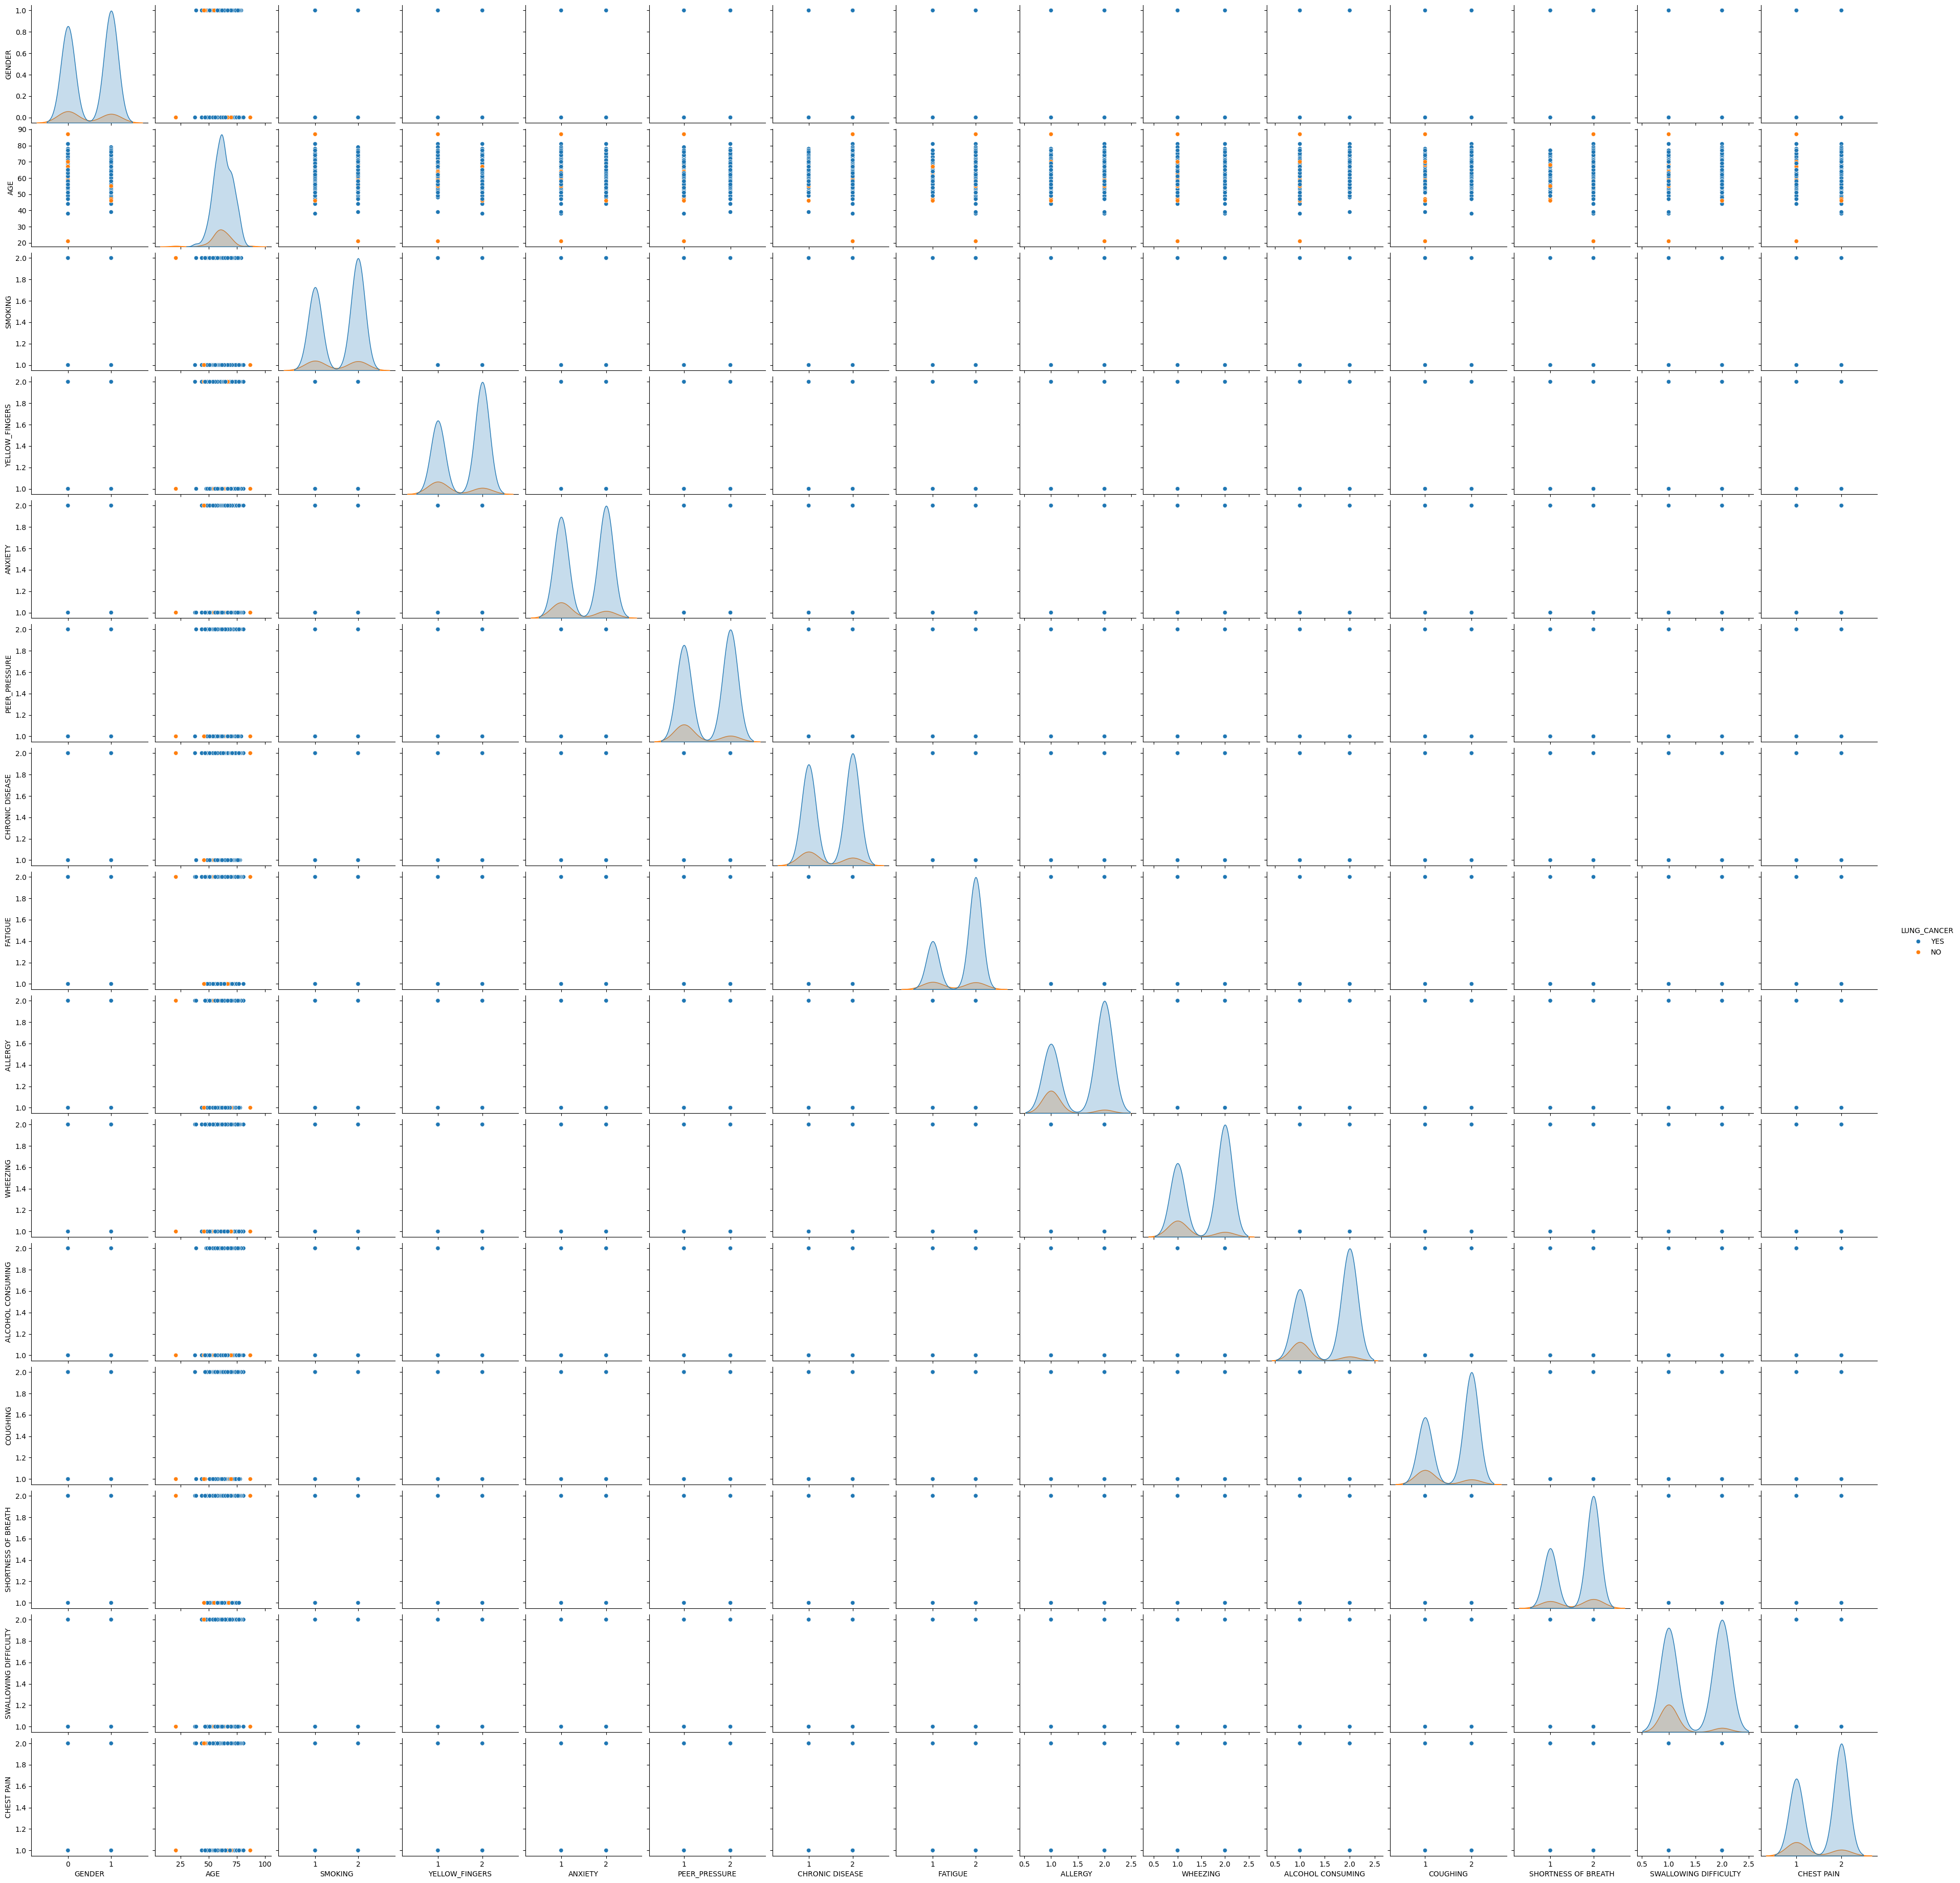

In [ ]:
sns.pairplot(df,hue='LUNG_CANCER')

<Axes: ylabel='AGE'>

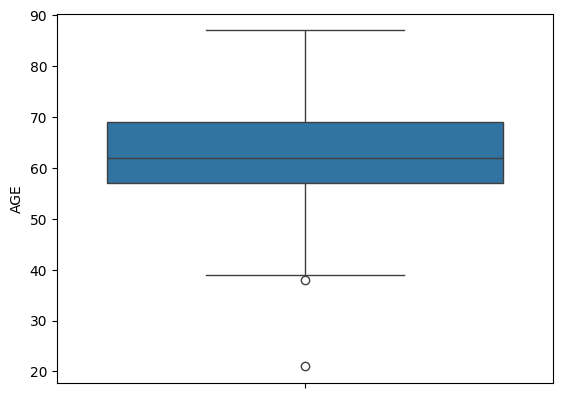

In [ ]:
sns.boxplot(df['AGE'])

In [ ]:
from scipy.stats import zscore
z_score= zscore(df['AGE'])
df[np.abs(z_score)>3]

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
22,0,21,2,1,1,1,2,2,2,1,1,1,2,1,1,NO
238,0,38,1,2,1,1,2,2,2,2,1,2,2,1,2,YES


<Axes: ylabel='AGE'>

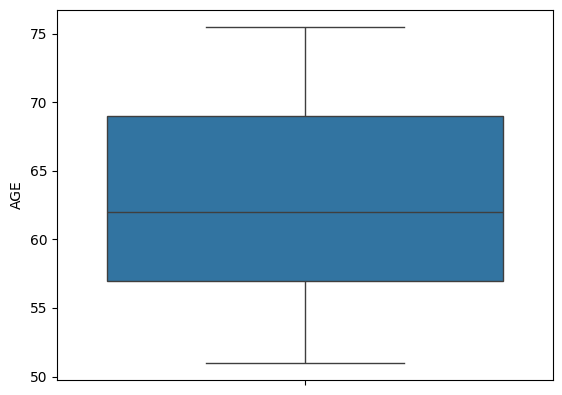

In [ ]:
low = df['AGE'].quantile(0.05)
up = df['AGE'].quantile(0.94)
df['AGE']=df['AGE'].clip(low,up)
sns.boxplot(df['AGE'])

In [ ]:
X = df.drop('LUNG_CANCER',axis=1)
y=df['LUNG_CANCER']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier(criterion="entropy")
dc.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
y_pred=dc.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9354838709677419
[[ 1  1]
 [ 3 57]]
              precision    recall  f1-score   support

          NO       0.25      0.50      0.33         2
         YES       0.98      0.95      0.97        60

    accuracy                           0.94        62
   macro avg       0.62      0.72      0.65        62
weighted avg       0.96      0.94      0.95        62



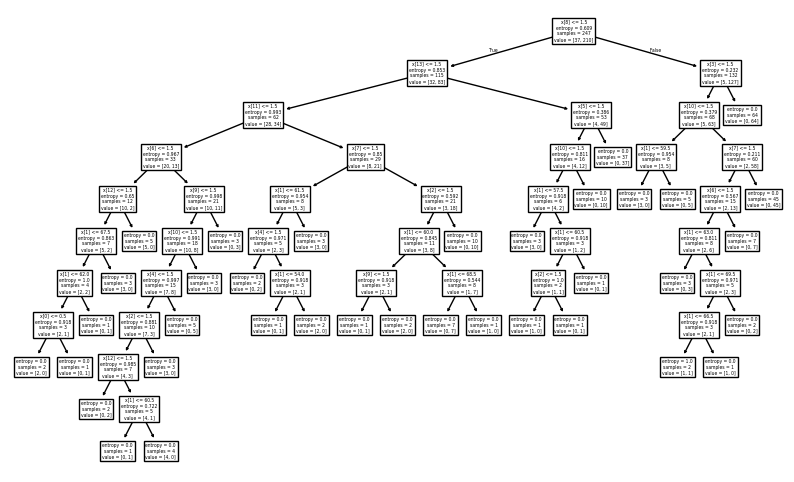

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
fig=plt.figure(figsize=(10,6))
tree.plot_tree(dc)
plt.show()

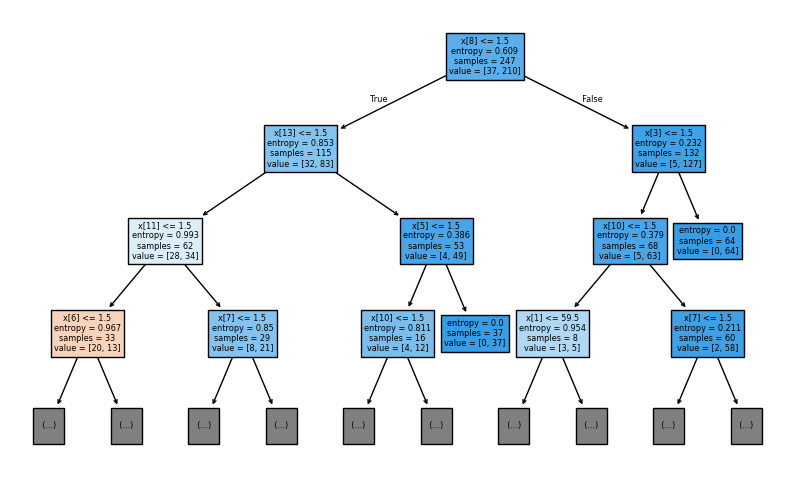

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
fig=plt.figure(figsize=(10,6))
tree.plot_tree(dc,max_depth=3,filled=True)
plt.show()